## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import missingno
import re

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../Modules")
sys.path.insert(0, "../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x0000013D5B5E7510> [0]

In [3]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'

In [4]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_GRID_2016-2018_filled.csv', encoding=enc)
wnv_file = pd.read_csv(f'../../data/{NUTS0}_WNV_cases_GRID_2010-2021.csv', encoding=enc)


In [5]:
timeline_file.head()

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,21.763340,40.798060,0,2016-01-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2016,1,0.322417,-0.083739,-0.311678,0.083739,0.317002,-0.081787,-0.306300,0.081787,0.012348,0.031579,0.012786,0.031579,14237.000000,13758.000000,0.304373,1,13979.000000,13652.161290,14312.047619,13841.952381,14394.032258,13811.645161,14815.133333,14107.866667,0.304373,0.304373,0.304373,0.304373,2.000000,3,2
1,21.763340,40.798060,0,2016-01-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2016,1,0.322417,-0.083739,-0.311678,0.083739,0.317002,-0.081787,-0.306300,0.081787,0.012348,0.031579,0.012786,0.031579,13840.000000,13758.000000,0.069506,2,13979.000000,13652.161290,14312.047619,13841.952381,14394.032258,13811.645161,14815.133333,14107.866667,0.373879,0.373879,0.373879,0.373879,2.000000,3,2
2,21.763340,40.798060,0,2016-01-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2016,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13840.000000,13758.000000,16.788566,3,13979.000000,13652.161290,14312.047619,13841.952381,14394.032258,13811.645161,14815.133333,14107.866667,17.162446,17.162446,17.162446,17.162446,2.000000,3,2
3,21.763340,40.798060,0,2016-01-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2016,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13840.000000,13758.000000,6.750442,4,13979.000000,13652.161290,14312.047619,13841.952381,14394.032258,13811.645161,14815.133333,14107.866667,23.912887,23.912887,23.912887,23.912887,2.000000,3,2
4,21.763340,40.798060,0,2016-01-05,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2016,1,0.322417,-0.083739,-0.311678,0.083739,0.317002,-0.081787,-0.306300,0.081787,0.012348,0.031579,0.012786,0.031579,13840.000000,13388.000000,0.590280,5,13979.000000,13652.161290,14312.047619,13841.952381,14394.032258,13811.645161,14815.133333,14107.866667,24.503167,24.503167,24.503167,24.503167,2.000000,3,2


In [6]:
timeline_file.shape

(4839936, 44)

In [7]:
wnv_file.head()

,cell_code,dt_placement,cases
0,AAK447,2010-05,0
1,AAK447,2010-06,0
2,AAK447,2010-07,0
3,AAK447,2010-08,0
4,AAK447,2010-09,0


In [8]:
wnv_file.shape

(52876, 3)

In [9]:
try:
    timeline_file.drop(columns=['Unnamed: 0'], inplace=True)
except KeyError:
    print ("column not found")

column not found


In [10]:
temprature_cols = timeline_file.filter(regex='^lst_*').columns.tolist()

timeline_file[temprature_cols] = timeline_file[temprature_cols].apply(lambda x : x * 0.02 - 273.15)

In [11]:
timeline_file.head()

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,21.763340,40.798060,0,2016-01-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2016,1,0.322417,-0.083739,-0.311678,0.083739,0.317002,-0.081787,-0.306300,0.081787,0.012348,0.031579,0.012786,0.031579,11.590000,2.010000,0.304373,1,6.430000,-0.106774,13.090952,3.689048,14.730645,3.082903,23.152667,9.007333,0.304373,0.304373,0.304373,0.304373,2.000000,3,2
1,21.763340,40.798060,0,2016-01-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2016,1,0.322417,-0.083739,-0.311678,0.083739,0.317002,-0.081787,-0.306300,0.081787,0.012348,0.031579,0.012786,0.031579,3.650000,2.010000,0.069506,2,6.430000,-0.106774,13.090952,3.689048,14.730645,3.082903,23.152667,9.007333,0.373879,0.373879,0.373879,0.373879,2.000000,3,2
2,21.763340,40.798060,0,2016-01-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2016,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.650000,2.010000,16.788566,3,6.430000,-0.106774,13.090952,3.689048,14.730645,3.082903,23.152667,9.007333,17.162446,17.162446,17.162446,17.162446,2.000000,3,2
3,21.763340,40.798060,0,2016-01-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2016,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.650000,2.010000,6.750442,4,6.430000,-0.106774,13.090952,3.689048,14.730645,3.082903,23.152667,9.007333,23.912887,23.912887,23.912887,23.912887,2.000000,3,2
4,21.763340,40.798060,0,2016-01-05,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2016,1,0.322417,-0.083739,-0.311678,0.083739,0.317002,-0.081787,-0.306300,0.081787,0.012348,0.031579,0.012786,0.031579,3.650000,-5.390000,0.590280,5,6.430000,-0.106774,13.090952,3.689048,14.730645,3.082903,23.152667,9.007333,24.503167,24.503167,24.503167,24.503167,2.000000,3,2


In [12]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [13]:
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['dt_placement'])
timeline_file['day'] = timeline_file['dt_placement'].apply(lambda x : x.day)
timeline_file['month'] = timeline_file['dt_placement'].apply(lambda x : x.month)
timeline_file['year'] = timeline_file['dt_placement'].apply(lambda x : x.year)

timeline_file = encode_cyclical(timeline_file, 'month', 12)

In [14]:
timeline_file.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

In [15]:
timeline_file

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,month_sin,month_cos
0,21.763340,40.798060,0,2016-01-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2016,1,0.322417,-0.083739,-0.311678,0.083739,0.317002,-0.081787,-0.306300,0.081787,0.012348,0.031579,0.012786,0.031579,11.590000,2.010000,0.304373,1,6.430000,-0.106774,13.090952,3.689048,14.730645,3.082903,23.152667,9.007333,0.304373,0.304373,0.304373,0.304373,2.000000,3,2,6.800000,3.161613,8.390000,8.906774,16.080000,0.500000,0.866025
1,21.763340,40.798060,0,2016-01-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2016,1,0.322417,-0.083739,-0.311678,0.083739,0.317002,-0.081787,-0.306300,0.081787,0.012348,0.031579,0.012786,0.031579,3.650000,2.010000,0.069506,2,6.430000,-0.106774,13.090952,3.689048,14.730645,3.082903,23.152667,9.007333,0.373879,0.373879,0.373879,0.373879,2.000000,3,2,2.830000,3.161613,8.390000,8.906774,16.080000,0.500000,0.866025
2,21.763340,40.798060,0,2016-01-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2016,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.650000,2.010000,16.788566,3,6.430000,-0.106774,13.090952,3.689048,14.730645,3.082903,23.152667,9.007333,17.162446,17.162446,17.162446,17.162446,2.000000,3,2,2.830000,3.161613,8.390000,8.906774,16.080000,0.500000,0.866025
3,21.763340,40.798060,0,2016-01-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2016,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.650000,2.010000,6.750442,4,6.430000,-0.106774,13.090952,3.689048,14.730645,3.082903,23.152667,9.007333,23.912887,23.912887,23.912887,23.912887,2.000000,3,2,2.830000,3.161613,8.390000,8.906774,16.080000,0.500000,0.866025
4,21.763340,40.798060,0,2016-01-05,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,2016,1,0.322417,-0.083739,-0.311678,0.083739,0.317002,-0.081787,-0.306300,0.081787,0.012348,0.031579,0.012786,0.031579,3.650000,-5.390000,0.590280,5,6.430000,-0.106774,13.090952,3.689048,14.730645,3.082903,23.152667,9.007333,24.503167,24.503167,24.503167,24.503167,2.000000,3,2,-0.870000,3.161613,8.390000,8.906774,16.080000,0.500000,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4839931,24.082170,40.995700,4415,2018-12-27,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL526,σερρες,αμφιπολης,2018,12,0.198149,-0.130382,-0.197142,0.130382,0.203739,-0.105573,-0.197259,0.105573,0.101297,0.112771,0.064730,0.112771,5.270000,-3.310000,0.000000,27,9.556452,-0.180323,13.760000,2.210714,17.980968,5.262258,27.161333,10.339333,17.174665,112.207197,144.389915,1325.149331,2.000000,3,1,0.980000,4.688065,7.985357,11.621613,18.750333,-0.000000,1.000000
4839932,24.082170,40.995700,4415,2018-12-28,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL526,σερρες,αμφιπολης,2018,12,0.198149,-0.130382,-0.197142,0.130382,0.203739,-0.105573,-0.197259,0.105573,0.101297,0.112771,0.064730,0.112771,5.910000,-3.310000,0.250176,28,9.556452,-0.180323,13.760000,2.210714,17.980968,5.262258,27.161333,10.339333,17.424841,112.435998,118.765849,1325.399507,2.000000,3,1,1.300000,4.688065,7.985357,11.621613,18.750333,-0.000000,1.000000
4839933,24.082170,40.995700,4415,2018-12-29,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL526,σερρες,αμφιπολης,2018,12,0.198149,-0.130382,-0.197142,0.130382,0.203739,-0.105573,-0.197259,0.105573,0.101297,0.112771,0.064730,0.112771,5.230000,-3.310000,6.

In [16]:
timeline_file.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)
timeline_file['date_string'] = timeline_file['month'].astype(str) + '-' + timeline_file['year'].astype(str)
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['date_string'], format='%m-%Y').dt.to_period('M')
timeline_file.drop(columns=['date_string'], inplace = True)

In [17]:
grouped_by_month = timeline_file.drop(columns=['dt_placement_daily']).groupby(['cell_number','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID', 'NUTS3_NAME', 'LAU1_NAME'], as_index = False)

grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_min = grouped_by_month.min()
grouped_by_month_max = grouped_by_month.max()
grouped_by_month_sum = grouped_by_month.sum()
grouped_by_month_last = grouped_by_month.last()

In [18]:
grouped_by_month_mean

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,month_sin,month_cos
0,0,2016-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2016.000000,1.000000,0.316791,-0.084546,-0.309917,0.084546,0.307212,-0.080409,-0.302734,0.080409,0.011876,0.043161,0.014922,0.043161,6.430000,-0.106774,4.884865,16.000000,6.430000,-0.106774,13.090952,3.689048,14.730645,3.082903,23.152667,9.007333,32.712594,64.817906,97.317081,97.326900,2.000000,3.000000,2.000000,3.161613,3.161613,8.390000,8.906774,16.080000,0.500000,0.866025
1,0,2016-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2016.000000,2.000000,0.308753,-0.085701,-0.307401,0.085701,0.293227,-0.078442,-0.297639,0.078442,0.011203,0.059706,0.017973,0.059706,13.090952,3.689048,2.712463,15.000000,6.430000,-0.106774,13.090952,3.689048,14.730645,3.082903,23.152667,9.007333,16.562986,30.258036,82.327120,181.133973,2.000000,3.000000,2.000000,8.390000,3.161613,8.390000,8.906774,16.080000,0.866025,0.500000
2,0,2016-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2016.000000,3.000000,0.170068,-0.005780,-0.182944,0.005780,0.188196,0.035042,-0.163391,-0.035042,0.046762,0.052049,0.056384,0.052049,14.730645,3.082903,6.452221,16.000000,6.430000,-0.106774,13.090952,3.689048,14.730645,3.082903,23.152667,9.007333,48.827809,96.508464,180.780206,362.612315,2.000000,3.000000,2.000000,8.906774,3.161613,8.390000,8.906774,16.080000,1.000000,0.000000
3,0,2016-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2016.000000,4.000000,0.415760,0.014507,-0.360760,-0.014507,0.394405,0.015751,-0.349497,-0.015751,0.037912,0.039548,0.025293,0.039548,23.152667,9.007333,2.347688,15.500000,6.430000,-0.106774,13.090952,3.689048,14.730645,3.082903,23.152667,9.007333,11.381612,21.778118,87.027149,453.977230,2.000000,3.000000,2.000000,16.080000,3.161613,8.390000,8.906774,16.080000,0.866025,-0.500000
4,0,2016-05,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2016.000000,5.000000,0.592660,0.153908,-0.483491,-0.153908,0.562457,0.146340,-0.467581,-0.146340,0.054131,0.061882,0.038305,0.061882,23.746129,9.877097,6.792094,16.000000,6.430000,-0.106774,13.090952,3.689048,14.730645,3.082903,23.152667,9.007333,52.057349,101.497561,180.902624,638.363856,2.000000,3.000000,2.000000,16.811613,3.161613,8.390000,8.906774,16.080000,0.500000,-0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158971,4415,2018-08,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL526,σερρες,αμφιπολης,24.082170,40.995700,2018.000000,8.000000,0.434752,0.047648,-0.408304,-0.047648,0.444132,0.058662,-0.416337,-0.058662,0.074232,0.073167,0.045819,0.073167,35.820323,20.286774,1.232289,16.000000,9.556452,-0.180323,13.760000,2.210714,17.980968,5.262258,27.161333,10.339333,13.413964,33.615552,104.360659,960.103043,2.000000,3.000000,1.000000,28.053548,4.688065,7.985357,11.621613,18.750333,-0.866025,-0.500000
158972,4415,2018-09,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL526,σερρες,αμφιπολης,24.082170,40.995700,2018.000000,9.000000,0.310474,-0.042530,-0.366413,0.042530,0.338970,-0.019356,-0.381101,0.019356,0.071819,0.072448,0.038295,0.072448,34.298667,16.083333,1.650333,15.500000,9.556452,-0.180323,13.760000,2.210714,17.980968,5.262258,27.161333,10.339333,6.643706,14.

In [19]:
grouped_by_month_dataset = pd.concat([grouped_by_month_mean[['cell_number','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','LAU1_NAME','x','y','MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']], 
                                     grouped_by_month_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_month_mean[['lst_day','lst_night','lst']].rename(columns={'lst_day': 'lst_day_mean', 'lst_night': 'lst_night_mean', 'lst': 'lst_mean'}),
                                     grouped_by_month_last[['lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean', 'lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']],
                                     grouped_by_month_mean[['rainfall']].rename(columns={'rainfall':'rainfall_mean'}),
                                     grouped_by_month_last[['acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan']],
                                     grouped_by_month_min[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_min', 'lst_night': 'lst_night_min'}),
                                     grouped_by_month_max[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_max', 'lst_night': 'lst_night_max'}),
                                     grouped_by_month_sum[['rainfall']].rename(columns={'rainfall':'rainfall_acc'})], axis=1)

In [20]:
grouped_by_month_dataset.head()

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,0,2016-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2016.000000,1.000000,0.316791,-0.084546,-0.309917,0.084546,0.307212,-0.080409,-0.302734,0.080409,0.011876,0.043161,0.014922,0.043161,6.430000,-0.106774,3.161613,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,4.884865,9.245614,9.251663,151.126434,151.430807,0.070000,-7.730000,13.950000,6.870000,151.430807
1,0,2016-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2016.000000,2.000000,0.308753,-0.085701,-0.307401,0.085701,0.293227,-0.078442,-0.297639,0.078442,0.011203,0.059706,0.017973,0.059706,13.090952,3.689048,8.390000,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,2.712463,25.155823,42.624069,85.824574,230.092241,4.530000,-2.390000,17.770000,6.930000,78.661435
2,0,2016-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2016.000000,3.000000,0.170068,-0.005780,-0.182944,0.005780,0.188196,0.035042,-0.163391,-0.035042,0.046762,0.052049,0.056384,0.052049,14.730645,3.082903,8.906774,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,6.452221,0.575541,28.231727,197.631731,430.111107,4.470000,-7.950000,25.750000,10.010000,200.018866
3,0,2016-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2016.000000,4.000000,0.415760,0.014507,-0.360760,-0.014507,0.394405,0.015751,-0.349497,-0.015751,0.037912,0.039548,0.025293,0.039548,23.152667,9.007333,16.080000,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,2.347688,41.221155,46.724297,70.430655,500.541762,13.910000,-0.250000,27.470000,14.270000,70.430655
4,0,2016-05,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2016.000000,5.000000,0.592660,0.153908,-0.483491,-0.153908,0.562457,0.146340,-0.467581,-0.146340,0.054131,0.061882,0.038305,0.061882,23.746129,9.877097,16.811613,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,6.792094,2.935894,94.619316,149.115361,711.096681,14.010000,-0.250000,28.790000,15.830000,210.554920


In [21]:
grouped_by_month_dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,0,2016-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2016.000000,1.000000,0.316791,-0.084546,-0.309917,0.084546,0.307212,-0.080409,-0.302734,0.080409,0.011876,0.043161,0.014922,0.043161,6.430000,-0.106774,3.161613,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,4.884865,9.245614,9.251663,151.126434,151.430807,0.070000,-7.730000,13.950000,6.870000,151.430807
1,0,2016-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2016.000000,2.000000,0.308753,-0.085701,-0.307401,0.085701,0.293227,-0.078442,-0.297639,0.078442,0.011203,0.059706,0.017973,0.059706,13.090952,3.689048,8.390000,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,2.712463,25.155823,42.624069,85.824574,230.092241,4.530000,-2.390000,17.770000,6.930000,78.661435
2,0,2016-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2016.000000,3.000000,0.170068,-0.005780,-0.182944,0.005780,0.188196,0.035042,-0.163391,-0.035042,0.046762,0.052049,0.056384,0.052049,14.730645,3.082903,8.906774,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,6.452221,0.575541,28.231727,197.631731,430.111107,4.470000,-7.950000,25.750000,10.010000,200.018866
3,0,2016-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2016.000000,4.000000,0.415760,0.014507,-0.360760,-0.014507,0.394405,0.015751,-0.349497,-0.015751,0.037912,0.039548,0.025293,0.039548,23.152667,9.007333,16.080000,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,2.347688,41.221155,46.724297,70.430655,500.541762,13.910000,-0.250000,27.470000,14.270000,70.430655
4,0,2016-05,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2.000000,3.000000,2.000000,2016.000000,5.000000,0.592660,0.153908,-0.483491,-0.153908,0.562457,0.146340,-0.467581,-0.146340,0.054131,0.061882,0.038305,0.061882,23.746129,9.877097,16.811613,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,6.792094,2.935894,94.619316,149.115361,711.096681,14.010000,-0.250000,28.790000,15.830000,210.554920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158971,4415,2018-08,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL526,σερρες,αμφιπολης,24.082170,40.995700,2.000000,3.000000,1.000000,2018.000000,8.000000,0.434752,0.047648,-0.408304,-0.047648,0.444132,0.058662,-0.416337,-0.058662,0.074232,0.073167,0.045819,0.073167,35.820323,20.286774,28.053548,9.556452,13.760000,17.980968,27.161333,-0.180323,2.210714,5.262258,10.339333,4.688065,7.985357,11.621613,18.750333,1.232289,16.968329,16.968329,30.109079,976.748815,29.250000,15.170000,39.770000,22.590000,38.200954
158972,4415,2018-09,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL526,σερρες,αμφιπολης,24.082170,40.995700,2.000000,3.000000,1.000000,2018.000000,9.000000,0.310474,-0.042530,-0.

In [22]:
grouped_by_month_dataset['lst_min'] = grouped_by_month_dataset.apply(lambda row: min(row['lst_day_min'], row['lst_night_min']), axis=1)
grouped_by_month_dataset['lst_max'] = grouped_by_month_dataset.apply(lambda row: max(row['lst_day_max'], row['lst_night_max']), axis=1)

In [23]:
grouped_by_month_dataset.drop(columns=['lst_day_min', 'lst_night_min', 'lst_day_max', 'lst_night_max'], inplace=True)

In [24]:
grouped_by_month_dataset[['MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']] = grouped_by_month_dataset[['MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']].astype(int)


In [25]:
grouped_by_month_dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max
0,0,2016-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2016,1,0.316791,-0.084546,-0.309917,0.084546,0.307212,-0.080409,-0.302734,0.080409,0.011876,0.043161,0.014922,0.043161,6.430000,-0.106774,3.161613,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,4.884865,9.245614,9.251663,151.126434,151.430807,151.430807,-7.730000,13.950000
1,0,2016-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2016,2,0.308753,-0.085701,-0.307401,0.085701,0.293227,-0.078442,-0.297639,0.078442,0.011203,0.059706,0.017973,0.059706,13.090952,3.689048,8.390000,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,2.712463,25.155823,42.624069,85.824574,230.092241,78.661435,-2.390000,17.770000
2,0,2016-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2016,3,0.170068,-0.005780,-0.182944,0.005780,0.188196,0.035042,-0.163391,-0.035042,0.046762,0.052049,0.056384,0.052049,14.730645,3.082903,8.906774,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,6.452221,0.575541,28.231727,197.631731,430.111107,200.018866,-7.950000,25.750000
3,0,2016-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2016,4,0.415760,0.014507,-0.360760,-0.014507,0.394405,0.015751,-0.349497,-0.015751,0.037912,0.039548,0.025293,0.039548,23.152667,9.007333,16.080000,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,2.347688,41.221155,46.724297,70.430655,500.541762,70.430655,-0.250000,27.470000
4,0,2016-05,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2016,5,0.592660,0.153908,-0.483491,-0.153908,0.562457,0.146340,-0.467581,-0.146340,0.054131,0.061882,0.038305,0.061882,23.746129,9.877097,16.811613,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,6.792094,2.935894,94.619316,149.115361,711.096681,210.554920,-0.250000,28.790000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158971,4415,2018-08,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL526,σερρες,αμφιπολης,24.082170,40.995700,2,3,1,2018,8,0.434752,0.047648,-0.408304,-0.047648,0.444132,0.058662,-0.416337,-0.058662,0.074232,0.073167,0.045819,0.073167,35.820323,20.286774,28.053548,9.556452,13.760000,17.980968,27.161333,-0.180323,2.210714,5.262258,10.339333,4.688065,7.985357,11.621613,18.750333,1.232289,16.968329,16.968329,30.109079,976.748815,38.200954,15.170000,39.770000
158972,4415,2018-09,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL526,σερρες,αμφιπολης,24.082170,40.995700,2,3,1,2018,9,0.310474,-0.042530,-0.366413,0.042530,0.338970,-0.019356,-0.381101,0.019356,0.071819,0.072448,0.038295,0.072448,34.298667,16.083333,25.191000,9.556452,13.760000,17.980968,27.161333,-0.180323,2.210714,5.262258,10.339333,4.688065,7.985357,11.621613,18.750333,1.650333,33.496088,33.496088,49.509990,1026.258805,49.509990,8.590000,40.750000
158973,4415,2018-10,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL526,σερρες,αμφιπολης,24.0

### Add Geomorphological and Land Cover/Use

In [26]:
dataset_locations = grouped_by_month_dataset[['x', 'y']].drop_duplicates(keep='first')
dataset_locations.reset_index(drop = True, inplace = True)

In [27]:
dataset_locations_per_year = grouped_by_month_dataset[['x', 'y', 'year']].drop_duplicates(keep='first')
dataset_locations_per_year.reset_index(drop = True, inplace = True)

In [28]:
dataset_locations

,x,y
0,21.763340,40.798060
1,21.763340,40.798060
2,21.763340,40.816030
3,21.763340,40.816030
4,21.763340,40.834000
...,...,...
7676,24.082170,40.977730
7677,24.082170,40.977730
7678,24.082170,40.995700
7679,24.082170,40.995700


In [29]:
dataset_locations_per_year

,x,y,year
0,21.763340,40.798060,2016
1,21.763340,40.798060,2016
2,21.763340,40.798060,2017
3,21.763340,40.798060,2017
4,21.763340,40.798060,2018
...,...,...,...
19631,24.082170,40.995700,2016
19632,24.082170,40.995700,2017
19633,24.082170,40.995700,2017
19634,24.082170,40.995700,2018


In [30]:
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_GRID_Geomorphological.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [31]:
distances, indicies = calculate_nearest_topological(dataset_locations, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 1.6280404571907199e-12


In [32]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

C:\Users\dimit\AppData\Local\Temp\ipykernel_5784\180837051.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)


In [33]:
dataset_geo = pd.concat([dataset_locations, df_geo], axis=1, join = 'outer')
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.763340,40.798060,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000
1,21.763340,40.798060,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000
2,21.763340,40.816030,2463.154314,575.852541,20,187.414374,897.449167,168.372446,0.000000,3.327142
3,21.763340,40.816030,2463.154314,575.852541,20,187.414374,897.449167,168.372446,0.000000,3.327142
4,21.763340,40.834000,3829.512564,2424.332192,15,132.525146,1204.950661,166.684023,0.000000,12.023969
...,...,...,...,...,...,...,...,...,...,...
7676,24.082170,40.977730,22644.595043,1241.501789,12,146.332865,305.914835,187.156531,0.000000,4.770158
7677,24.082170,40.977730,22644.595043,1241.501789,12,146.332865,305.914835,187.156531,0.000000,4.770158
7678,24.082170,40.995700,23652.015602,77.289431,6,67.526103,89.811181,175.312728,0.000000,87.702619
7679,24.082170,40.995700,23652.015602,77.289431,6,67.526103,89.811181,175.312728,0.000000,87.702619


In [34]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km         object
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [35]:
dataset_geo['slope_mean_1km'] = pd.to_numeric(dataset_geo['slope_mean_1km'], errors='coerce').astype('int64')

In [36]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km          int64
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [37]:
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.763340,40.798060,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000
1,21.763340,40.798060,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000
2,21.763340,40.816030,2463.154314,575.852541,20,187.414374,897.449167,168.372446,0.000000,3.327142
3,21.763340,40.816030,2463.154314,575.852541,20,187.414374,897.449167,168.372446,0.000000,3.327142
4,21.763340,40.834000,3829.512564,2424.332192,15,132.525146,1204.950661,166.684023,0.000000,12.023969
...,...,...,...,...,...,...,...,...,...,...
7676,24.082170,40.977730,22644.595043,1241.501789,12,146.332865,305.914835,187.156531,0.000000,4.770158
7677,24.082170,40.977730,22644.595043,1241.501789,12,146.332865,305.914835,187.156531,0.000000,4.770158
7678,24.082170,40.995700,23652.015602,77.289431,6,67.526103,89.811181,175.312728,0.000000,87.702619
7679,24.082170,40.995700,23652.015602,77.289431,6,67.526103,89.811181,175.312728,0.000000,87.702619


In [38]:
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_GRID_Landcover_2001-2022.csv')
landcover.columns = landcover.columns.str.lower()

In [39]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [40]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [41]:
data_years = dataset_locations_per_year['year'].unique().tolist()

In [42]:
for year in data_years:
    frame_name = f'dataset_unique_points_annual_{year}'
    locals()[frame_name] = dataset_locations_per_year.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [43]:
landcover_2023 = landcover_2022

In [44]:
for year in data_years:
    data_name = f'dataset_unique_points_annual_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_unique_points_annual_part{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = pd.concat([df_lulc, locals()[lc_name].iloc[[index]]], ignore_index=True)

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2016
Min distance: 0.0
Max distance: 1.5124900532045132e-12
Year: 2017
Min distance: 0.0
Max distance: 1.6280404571907199e-12
Year: 2018
Min distance: 0.0
Max distance: 1.6280404571907199e-12


In [45]:
dataset_lulc = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_unique_points_annual_part{year}'
    dataset_lulc = pd.concat([dataset_lulc, locals()[merged_name]], ignore_index=True)

In [46]:
dataset_lulc

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,21.763340,40.798060,2016,22,70.000000,20,70.000000,20,70.000000,9,9,4,4,4,2,0
1,21.763340,40.798060,2016,22,70.000000,20,70.000000,20,70.000000,9,9,4,4,4,2,0
2,21.763340,40.816030,2016,22,83.000000,20,83.000000,20,83.000000,9,9,4,4,4,2,0
3,21.763340,40.816030,2016,22,83.000000,20,83.000000,20,83.000000,9,9,4,4,4,2,0
4,21.763340,40.834000,2016,31,96.000000,30,96.000000,30,96.000000,10,10,1,6,6,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19631,24.058750,41.013660,2018,31,98.000000,36,98.000000,30,98.000000,12,12,3,5,8,2,0
19632,24.082170,40.959760,2018,14,98.000000,10,98.000000,10,98.000000,4,4,6,4,4,2,0
19633,24.082170,40.977730,2018,11,83.000000,10,75.000000,10,75.000000,1,1,7,1,1,2,0
19634,24.082170,40.995700,2018,31,91.000000,36,92.000000,30,91.000000,12,12,3,5,8,2,0


In [47]:
dataset_lulc.dtypes

x                      float64
y                      float64
year                     int32
lc_prop1                 int64
lc_prop1_assessment    float64
lc_prop2                 int64
lc_prop2_assessment    float64
lc_prop3                 int64
lc_prop3_assessment    float64
lc_type1                 int64
lc_type2                 int64
lc_type3                 int64
lc_type4                 int64
lc_type5                 int64
lw                       int64
qc                       int64
dtype: object

In [48]:
grouped_by_month_dataset = pd.merge(grouped_by_month_dataset, dataset_geo, on=['x', 'y'], how='left')

In [49]:
grouped_by_month_dataset = pd.merge(grouped_by_month_dataset, dataset_lulc, on=['x', 'y', 'year'], how='left')

### Add Bio Variables ###

In [50]:
bio_values_df = grouped_by_month_dataset[['cell_number','year','month','rainfall_acc','lst_min','lst_max']]

In [51]:
bio_values_df.head(15)

,cell_number,year,month,rainfall_acc,lst_min,lst_max
0,0,2016,1,151.430807,-7.730000,13.950000
1,0,2016,2,78.661435,-2.390000,17.770000
2,0,2016,3,200.018866,-7.950000,25.750000
3,0,2016,4,70.430655,-0.250000,27.470000
4,0,2016,5,210.554920,-0.250000,28.790000
5,0,2016,6,70.552006,13.870000,37.250000
6,0,2016,7,46.721110,13.650000,36.970000
7,0,2016,8,126.369417,15.010000,35.710000
8,0,2016,9,285.983732,8.670000,30.710000
9,0,2016,10,133.790827,0.770000,26.650000


In [52]:
wnv_file.head(5)

,cell_code,dt_placement,cases
0,AAK447,2010-05,0
1,AAK447,2010-06,0
2,AAK447,2010-07,0
3,AAK447,2010-08,0
4,AAK447,2010-09,0


In [53]:
wnv_file

,cell_code,dt_placement,cases
0,AAK447,2010-05,0
1,AAK447,2010-06,0
2,AAK447,2010-07,0
3,AAK447,2010-08,0
4,AAK447,2010-09,0
...,...,...,...
52871,RN287,2021-06,0
52872,RN287,2021-07,0
52873,RN287,2021-08,0
52874,RN287,2021-09,0


In [54]:
grouped_by_month_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158976 entries, 0 to 158975
Data columns (total 72 columns):
 #   Column               Non-Null Count   Dtype    
---  ------               --------------   -----    
 0   cell_number          158976 non-null  int64    
 1   dt_placement         158976 non-null  period[M]
 2   NUTS1_ID             158976 non-null  object   
 3   NUTS1_NAME           158976 non-null  object   
 4   NUTS2_ID             158976 non-null  object   
 5   NUTS2_NAME           158976 non-null  object   
 6   NUTS3_ID             158976 non-null  object   
 7   NUTS3_NAME           158976 non-null  object   
 8   LAU1_NAME            158976 non-null  object   
 9   x                    158976 non-null  float64  
 10  y                    158976 non-null  float64  
 11  MOUNT_TYPE           158976 non-null  int32    
 12  URBN_TYPE            158976 non-null  int32    
 13  COAST_TYPE           158976 non-null  int32    
 14  year                 158976 non-null

In [55]:
wnv_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52876 entries, 0 to 52875
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cell_code     52876 non-null  object
 1   dt_placement  52876 non-null  object
 2   cases         52876 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


In [56]:
wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [57]:
wnv_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52876 entries, 0 to 52875
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype    
---  ------        --------------  -----    
 0   cell_code     52876 non-null  object   
 1   dt_placement  52876 non-null  period[M]
 2   cases         52876 non-null  int64    
dtypes: int64(1), object(1), period[M](1)
memory usage: 1.2+ MB


In [58]:
wnv_file

,cell_code,dt_placement,cases
0,AAK447,2010-05,0
1,AAK447,2010-06,0
2,AAK447,2010-07,0
3,AAK447,2010-08,0
4,AAK447,2010-09,0
...,...,...,...
52871,RN287,2021-06,0
52872,RN287,2021-07,0
52873,RN287,2021-08,0
52874,RN287,2021-09,0


In [59]:
wnv_file['cases'].value_counts()

cases
0    51635
1     1135
2       83
3       17
4        4
6        2
Name: count, dtype: int64

In [60]:
wnv_file.cases.sum()

1380

In [61]:
# merged = grouped_by_month_dataset.merge(wnv_file, how='left', on=['dt_placement', 'cell_code'] )
merged = grouped_by_month_dataset

In [62]:
merged

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,0,2016-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2016,1,0.316791,-0.084546,-0.309917,0.084546,0.307212,-0.080409,-0.302734,0.080409,0.011876,0.043161,0.014922,0.043161,6.430000,-0.106774,3.161613,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,4.884865,9.245614,9.251663,151.126434,151.430807,151.430807,-7.730000,13.950000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,22,70.000000,20,70.000000,20,70.000000,9,9,4,4,4,2,0
1,0,2016-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2016,2,0.308753,-0.085701,-0.307401,0.085701,0.293227,-0.078442,-0.297639,0.078442,0.011203,0.059706,0.017973,0.059706,13.090952,3.689048,8.390000,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,2.712463,25.155823,42.624069,85.824574,230.092241,78.661435,-2.390000,17.770000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,22,70.000000,20,70.000000,20,70.000000,9,9,4,4,4,2,0
2,0,2016-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2016,3,0.170068,-0.005780,-0.182944,0.005780,0.188196,0.035042,-0.163391,-0.035042,0.046762,0.052049,0.056384,0.052049,14.730645,3.082903,8.906774,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,6.452221,0.575541,28.231727,197.631731,430.111107,200.018866,-7.950000,25.750000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,22,70.000000,20,70.000000,20,70.000000,9,9,4,4,4,2,0
3,0,2016-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2016,4,0.415760,0.014507,-0.360760,-0.014507,0.394405,0.015751,-0.349497,-0.015751,0.037912,0.039548,0.025293,0.039548,23.152667,9.007333,16.080000,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,2.347688,41.221155,46.724297,70.430655,500.541762,70.430655,-0.250000,27.470000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,22,70.000000,20,70.000000,20,70.000000,9,9,4,4,4,2,0
4,0,2016-05,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2016,5,0.592660,0.153908,-0.483491,-0.153908,0.562457,0.146340,-0.467581,-0.146340,0.054131,0.061882,0.038305,0.061882,23.746129,9.877097,16.811613,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,6.792094,2.935894,94.619316,149.115361,711.096681,210.554920,-0.250000,28.790000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,22,70.000000,20,70.000000,20,70.000000,9,9,4,4,4,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1589

In [63]:
# merged = fillna(merged,{'cases': 0})

In [64]:
# merged['cases'].value_counts()

In [65]:
# merged.cases.sum()

In [66]:
# merged = merged.astype({'cases': 'int'})

<Axes: >

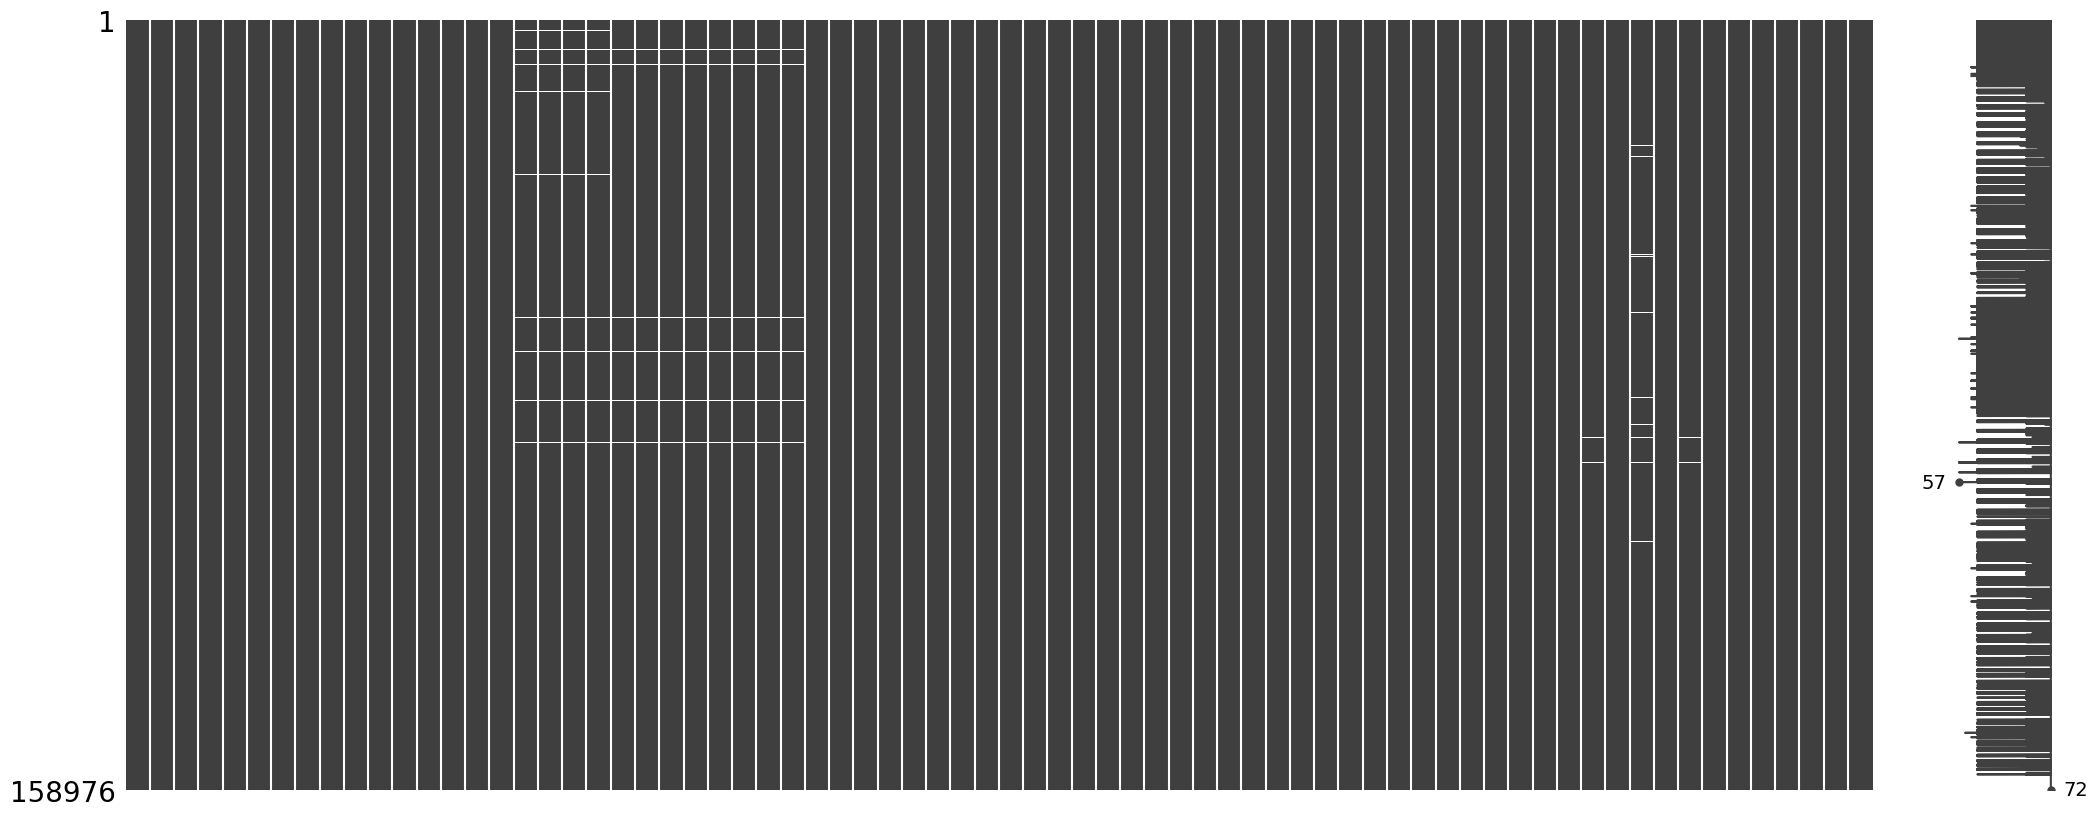

In [67]:
missingno.matrix(merged)

In [68]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'lst_min', 'lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)
imputed_columns = ['lst_min', 'lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

<Axes: >

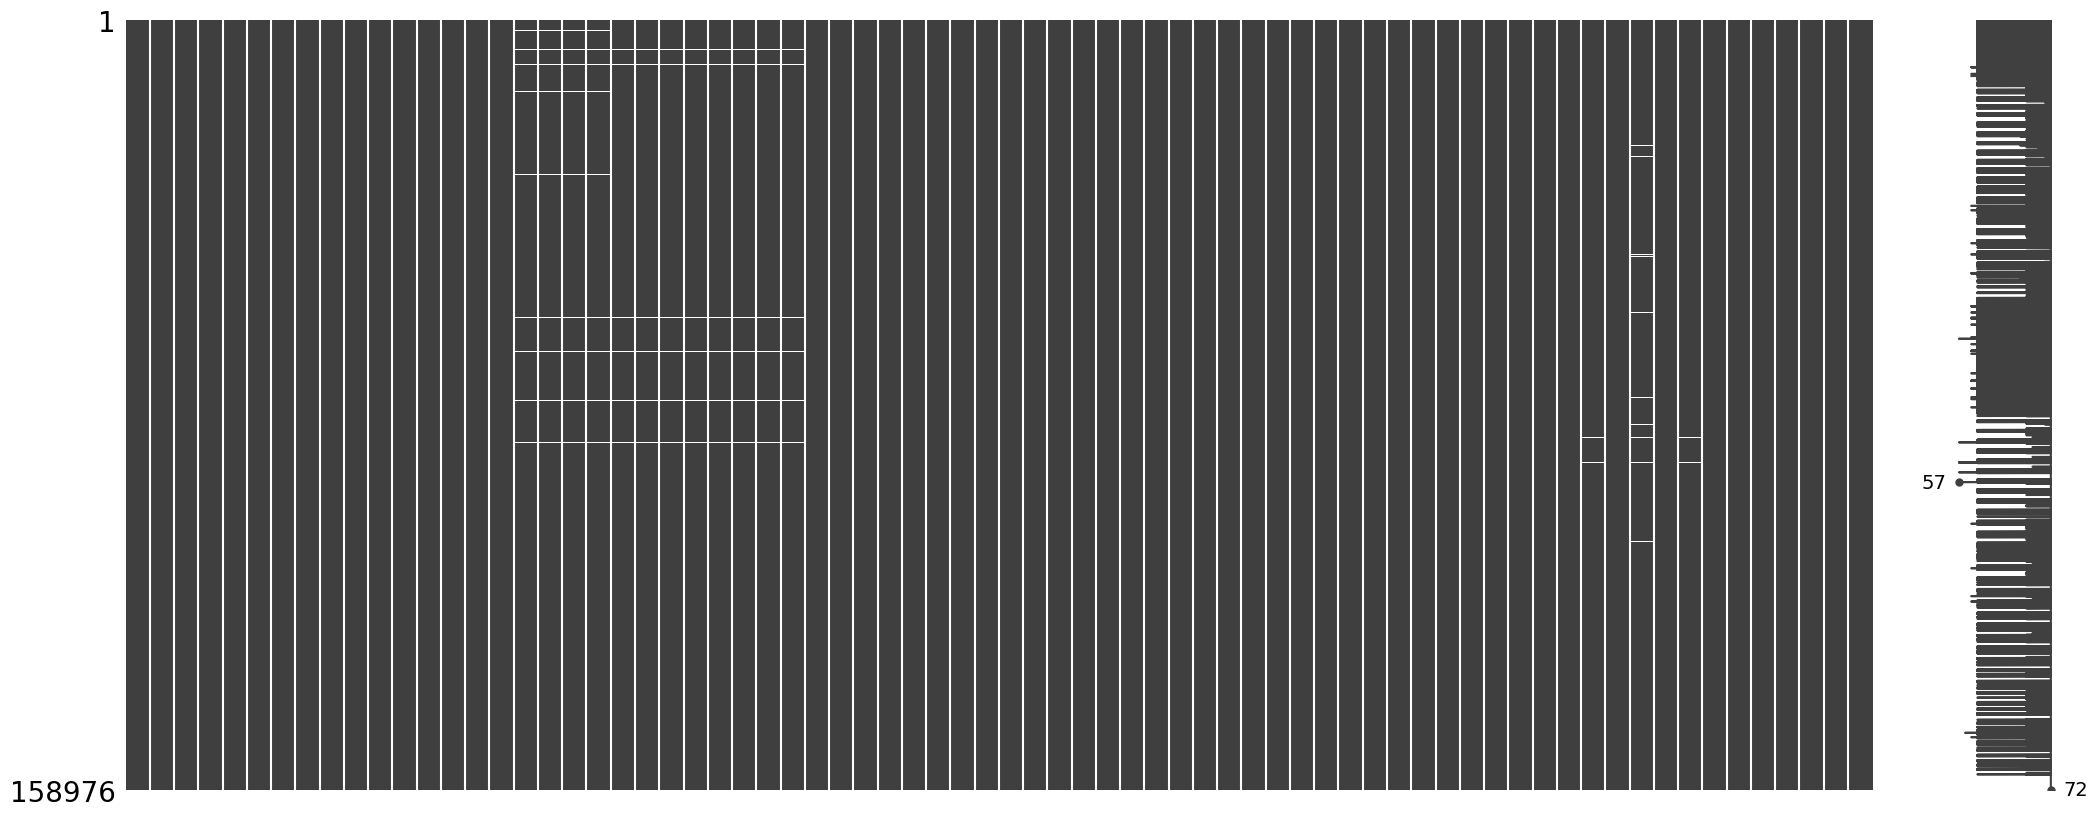

In [69]:
missingno.matrix(merged)

In [70]:
years = merged.year.unique()
years

array([2016, 2017, 2018])

In [71]:
cell_codes_un = merged.cell_number.unique()
cell_codes_un

array([   0,    1,    2, ..., 4413, 4414, 4415], dtype=int64)

In [72]:
rows = []
for year in years:
    for cell in cell_codes_un:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['cell_number'] == cell)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['rainfall_acc'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'cell_number': cell, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [73]:
biovars_df.head(20)

,cell_number,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,0,2016,13.250000,23.666667,52.592593,861.420603,37.000000,-8.000000,45.000000,19.000000,6.166667,24.833333,2.833333,1461.000000,285.000000,18.000000,63.870641,544.000000,225.000000,242.000000,243.000000
1,1,2016,12.750000,24.333333,56.589147,711.113084,34.000000,-9.000000,43.000000,17.000000,6.833333,21.166667,3.833333,1444.000000,264.000000,17.000000,60.161585,517.000000,223.000000,247.000000,242.000000
2,2,2016,12.083333,23.333333,54.263566,666.685606,32.000000,-11.000000,43.000000,15.000000,6.833333,20.166667,3.333333,1444.000000,264.000000,17.000000,60.161585,517.000000,223.000000,247.000000,249.000000
3,3,2016,11.166667,20.333333,52.136752,581.273419,28.000000,-11.000000,39.000000,13.666667,6.666667,18.000000,3.666667,1444.000000,264.000000,17.000000,60.161585,517.000000,223.000000,247.000000,249.000000
4,4,2016,14.625000,13.083333,42.204301,699.390969,31.000000,0.000000,31.000000,20.000000,10.333333,23.500000,6.000000,1461.000000,285.000000,18.000000,63.870641,544.000000,225.000000,242.000000,247.000000
5,5,2016,13.000000,25.000000,54.347826,814.359760,35.000000,-11.000000,46.000000,17.333333,5.500000,23.833333,2.833333,1444.000000,264.000000,17.000000,60.161585,517.000000,223.000000,247.000000,242.000000
6,6,2016,13.500000,23.166667,51.481481,830.114998,35.000000,-10.000000,45.000000,17.666667,5.333333,23.666667,2.333333,1444.000000,264.000000,17.000000,60.161585,517.000000,223.000000,247.000000,242.000000
7,7,2016,12.125000,21.250000,54.487179,618.328024,30.000000,-9.000000,39.000000,15.500000,6.666667,19.000000,3.833333,1444.000000,264.000000,17.000000,60.161585,517.000000,223.000000,247.000000,242.000000
8,8,2016,13.250000,9.666667,35.802469,705.336799,28.000000,1.000000,27.000000,19.000000,10.000000,22.333333,4.666667,1451.000000,282.000000,27.000000,63.274922,531.000000,222.000000,241.000000,251.000000
9,9,2016,13.041667,11.083333,38.218391,707.896478,29.000000,0.000000,29.000000,18.166667,9.000000,22.500000,4.666667,1451.000000,282.000000,27.000000,63.274922,531.000000,222.000000,241.000000,251.000000


In [74]:
merged = pd.merge(merged, biovars_df,  how='left', on=['cell_number', 'year'])

In [75]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2017) & (merged['cell_number'] == 0)]

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
12,0,2017-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2017,1,0.309049,-0.093949,-0.291225,0.093949,0.296032,-0.096063,-0.285041,0.096063,0.016985,0.033386,0.016843,0.033386,3.481613,-2.502258,0.489677,3.481613,9.942143,16.799032,21.175333,-2.502258,-3.708571,3.876452,5.038000,0.489677,3.116786,10.337742,13.106667,3.717113,12.411311,69.819269,115.186849,115.230505,115.230505,-12.370000,8.090000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,22,74.000000,20,74.000000,20,74.000000,9,9,4,4,4,2,0,13.625000,24.916667,43.713450,1052.513226,41.000000,-16.000000,57.000000,1.666667,19.666667,26.666667,0.000000,1245.000000,284.000000,38.000000,66.775079,555.000000,151.000000,208.000000,331.000000
13,0,2017-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2017,2,0.308479,-0.095711,-0.291832,0.095711,0.295371,-0.097763,-0.285444,0.097763,0.016948,0.032865,0.016704,0.032865,9.942143,-3.708571,3.116786,3.481613,9.942143,16.799032,21.175333,-2.502258,-3.708571,3.876452,5.038000,0.489677,3.116786,10.337742,13.106667,2.160814,19.837339,21.484744,60.502786,175.733291,60.502786,-16.050000,18.410000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,22,74.000000,20,74.000000,20,74.000000,9,9,4,4,4,2,0,13.625000,24.916667,43.713450,1052.513226,41.000000,-16.000000,57.000000,1.666667,19.666667,26.666667,0.000000,1245.000000,284.000000,38.000000,66.775079,555.000000,151.000000,208.000000,331.000000
14,0,2017-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2017,3,0.303289,-0.131780,-0.310015,0.131780,0.288830,-0.131917,-0.300126,0.131917,0.018152,0.023374,0.014461,0.023374,16.799032,3.876452,10.337742,3.481613,9.942143,16.799032,21.175333,-2.502258,-3.708571,3.876452,5.038000,0.489677,3.116786,10.337742,13.106667,2.721748,1.887299,4.787975,63.877216,260.107482,84.374191,0.330000,27.410000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,22,74.000000,20,74.000000,20,74.000000,9,9,4,4,4,2,0,13.625000,24.916667,43.713450,1052.513226,41.000000,-16.000000,57.000000,1.666667,19.666667,26.666667,0.000000,1245.000000,284.000000,38.000000,66.775079,555.000000,151.000000,208.000000,331.000000
15,0,2017-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2017,4,0.328463,-0.081889,-0.326864,0.081889,0.319196,-0.077346,-0.323261,0.077346,0.030430,0.032091,0.018107,0.032091,21.175333,5.038000,13.106667,3.481613,9.942143,16.799032,21.175333,-2.502258,-3.708571,3.876452,5.038000,0.489677,3.116786,10.337742,13.106667,1.890473,18.636660,24.226872,56.714193,316.821675,56.714193,-4.430000,28.070000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,22,74.000000,20,74.000000,20,74.000000,9,9,4,4,4,2,0,13.625000,24.916667,43.713450,1052.513226,41.000000,-16.000000,57.000000,1.666667,19.666667,26.666667,0.000000,1245.000000,284.000000,38.000000,66.775079,555.0

In [76]:
df_demographics = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\GR_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [77]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [78]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [79]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [80]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

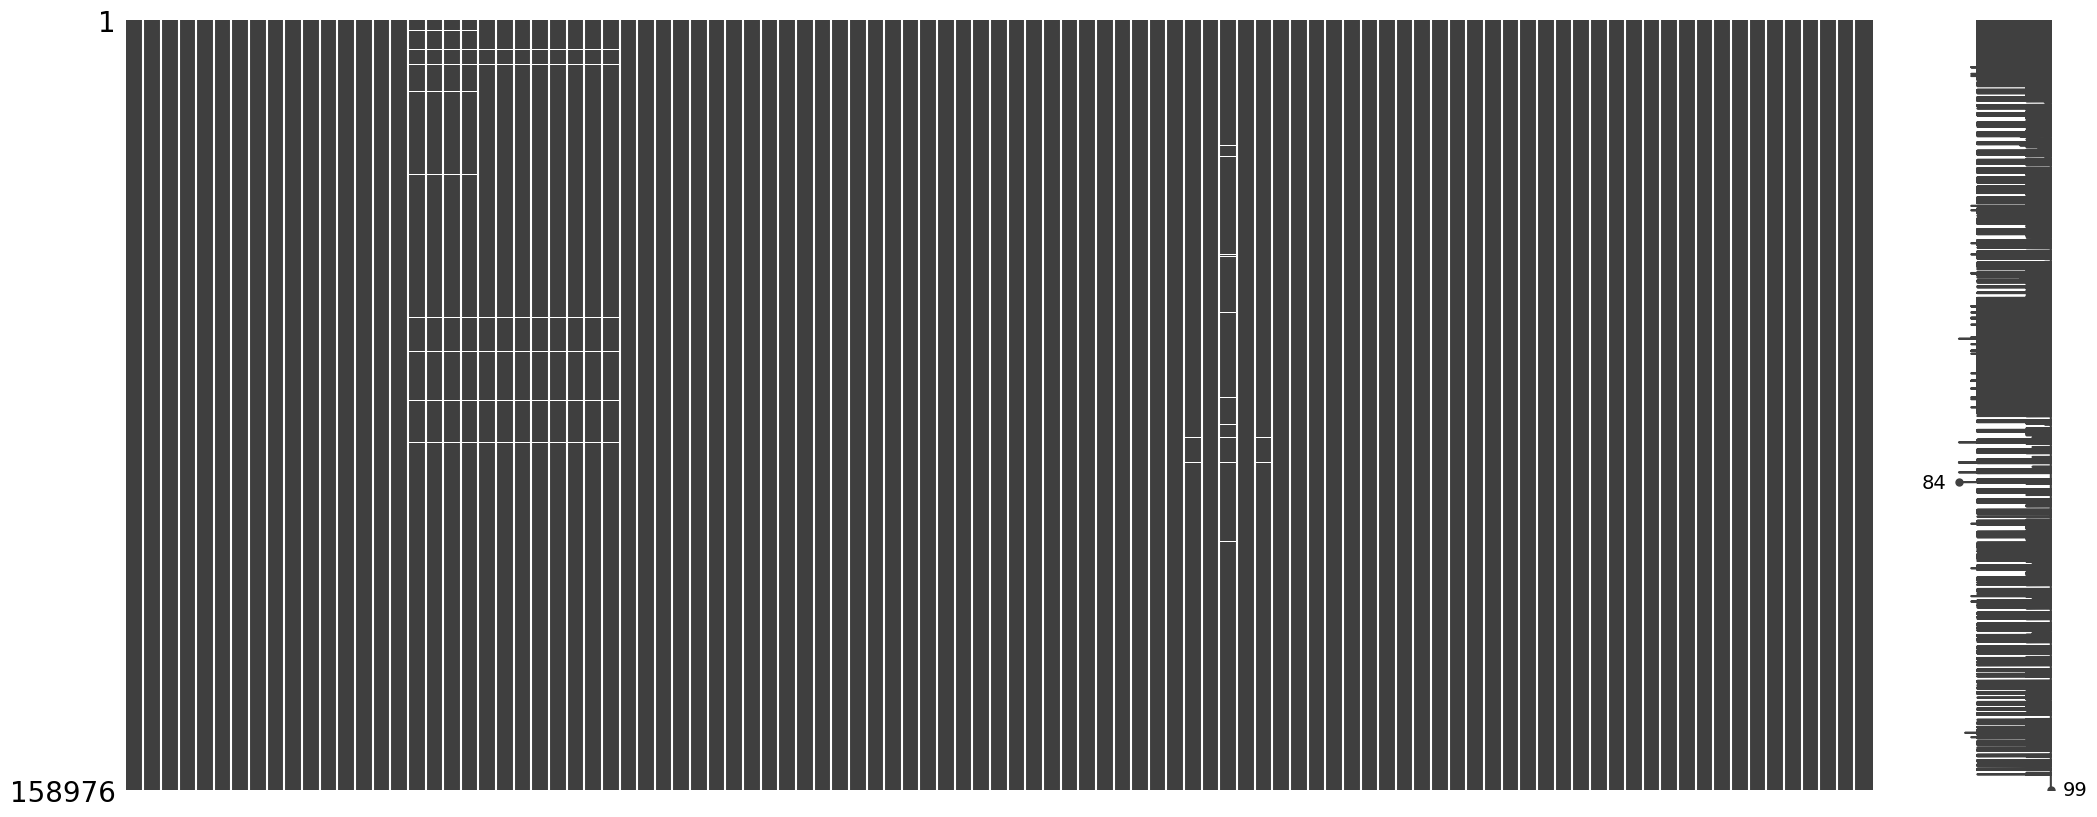

In [81]:
missingno.matrix(dataset)

In [82]:
df_economics = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\GR_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [83]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [84]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [85]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [86]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

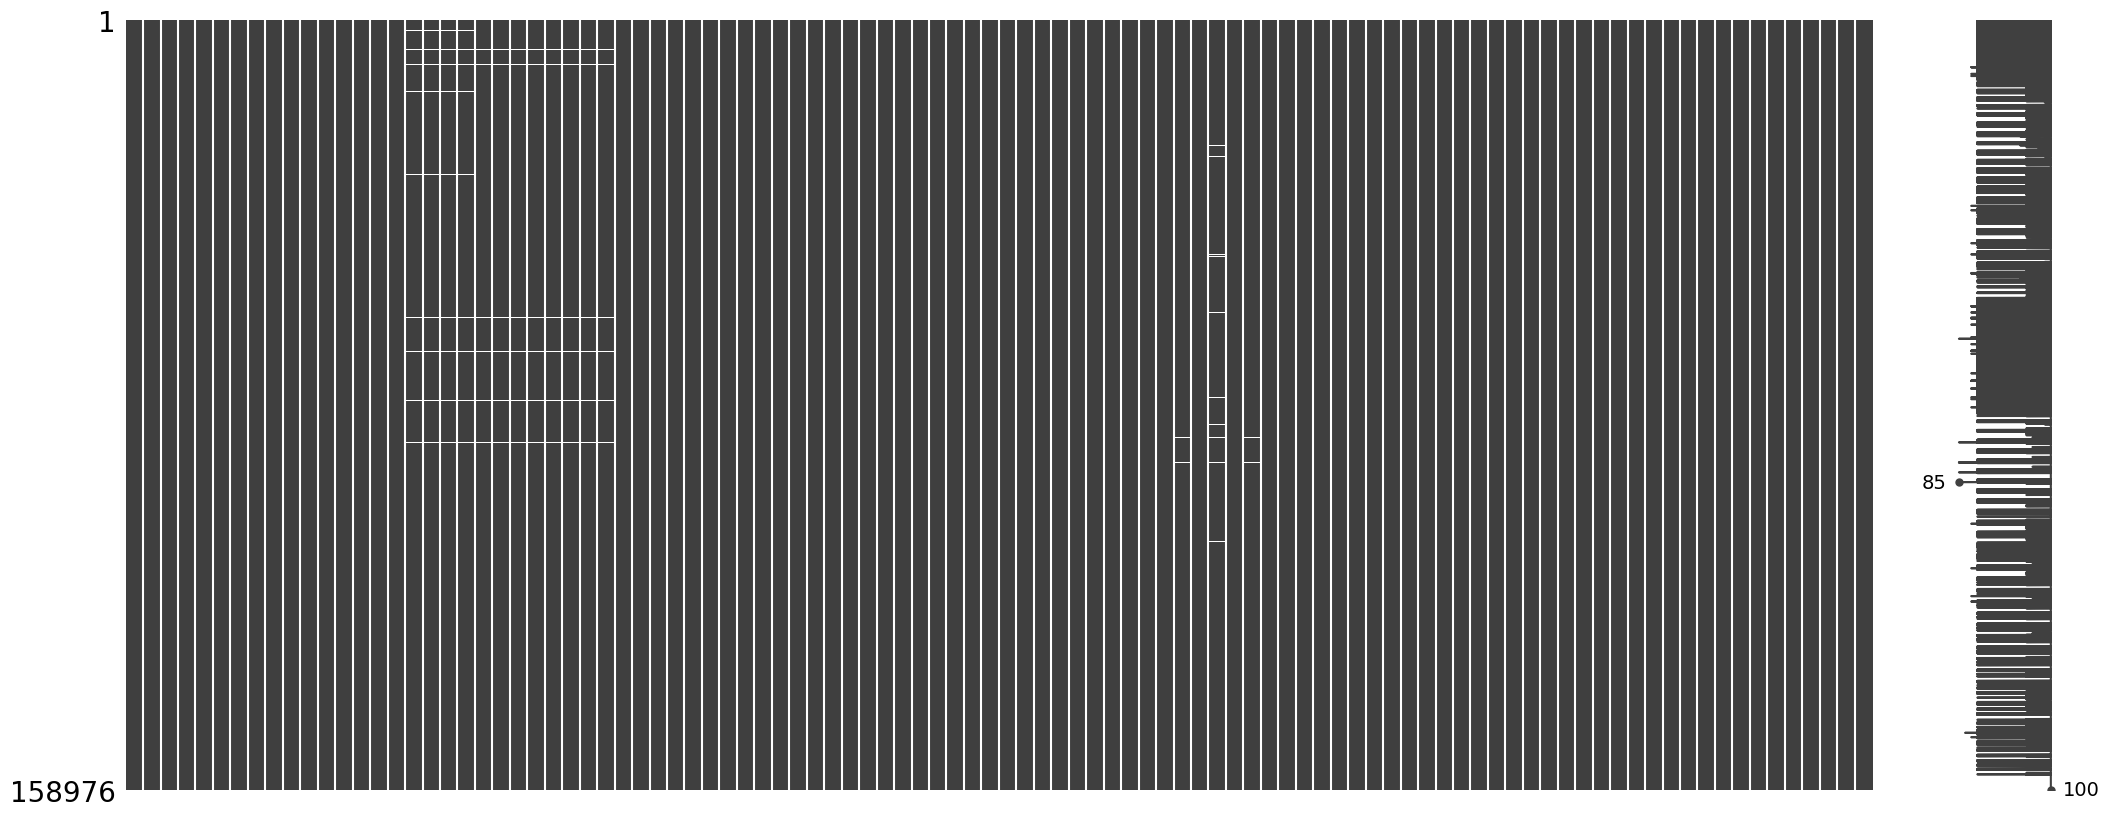

In [87]:
missingno.matrix(dataset)

In [88]:
df_trade = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\GR_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [89]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [90]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [91]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [92]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

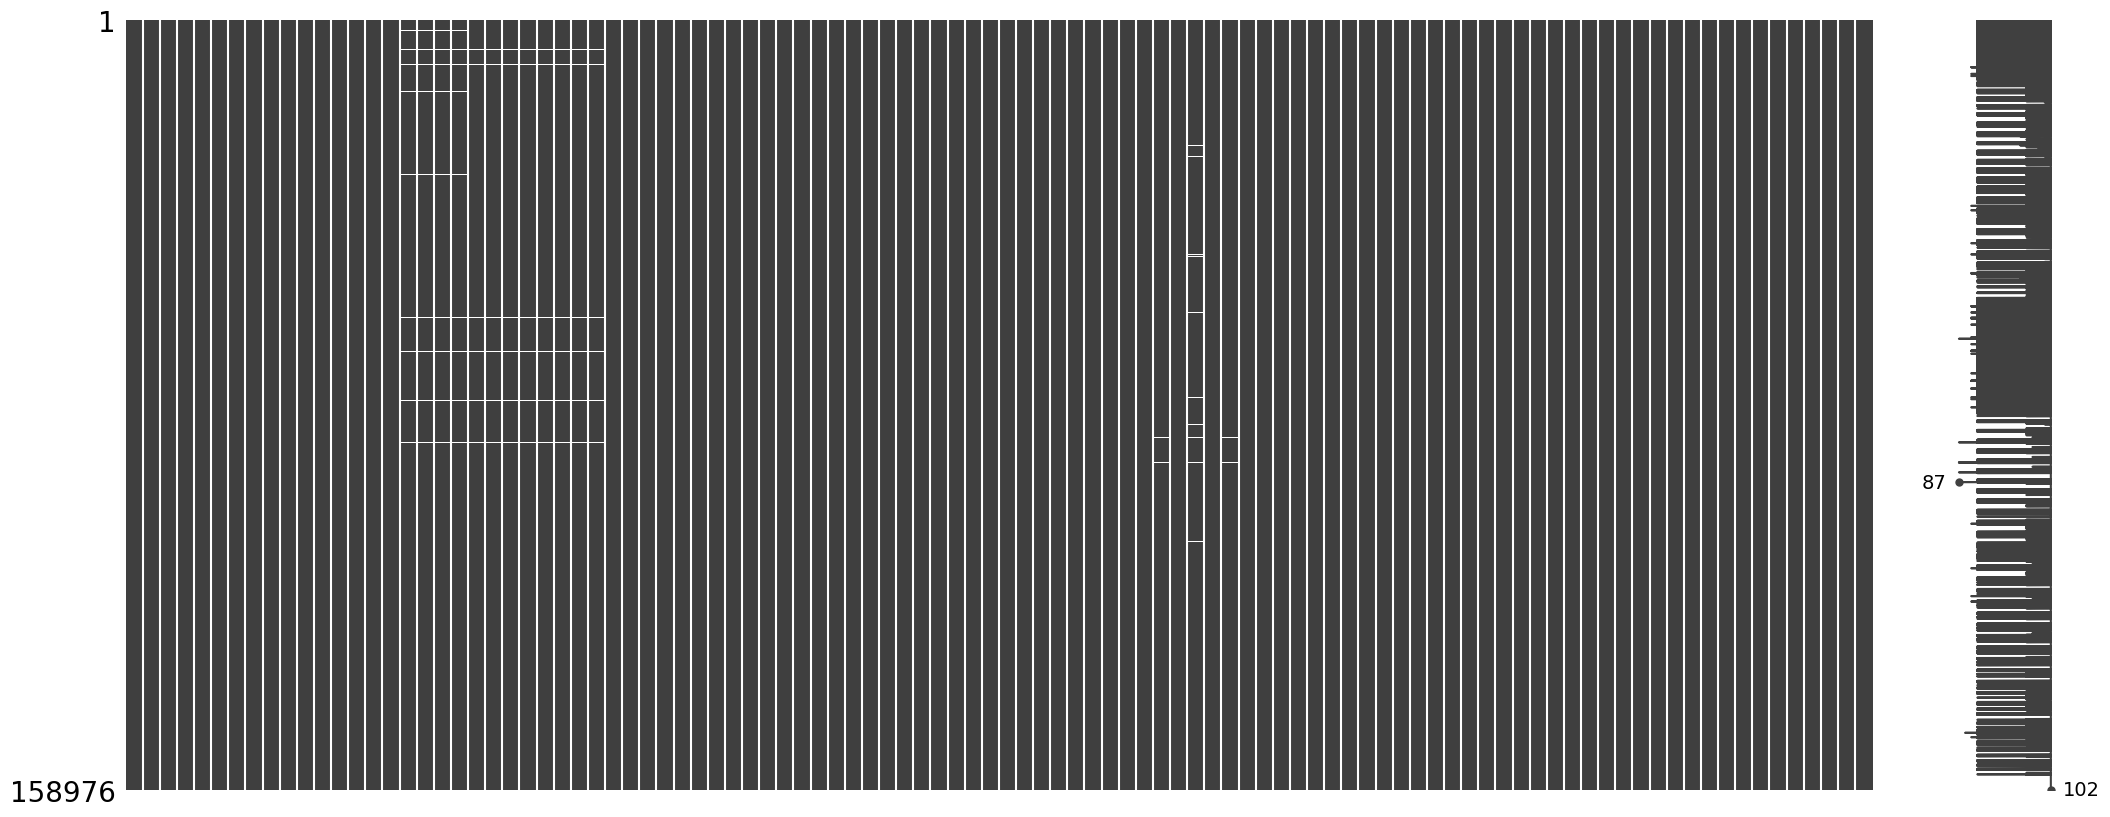

In [93]:
missingno.matrix(dataset)

In [94]:
missing = describe_dataframe(dataset, remove_zeros=True)

In [95]:
missing

,Column,Missing
16,ndvi,1.973900
17,ndmi,1.973900
18,ndwi,1.973900
19,ndbi,1.973900
20,ndvi_mean,1.465600
21,ndmi_mean,1.465600
22,ndwi_mean,1.465600
23,ndbi_mean,1.465600
24,ndvi_std,1.465600
25,ndmi_std,1.465600


In [96]:
dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2016-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2016,1,0.316791,-0.084546,-0.309917,0.084546,0.307212,-0.080409,-0.302734,0.080409,0.011876,0.043161,0.014922,0.043161,6.430000,-0.106774,3.161613,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,4.884865,9.245614,9.251663,151.126434,151.430807,151.430807,-7.730000,13.950000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,22,70.000000,20,70.000000,20,70.000000,9,9,4,4,4,2,0,13.250000,23.666667,52.592593,861.420603,37.000000,-8.000000,45.000000,19.000000,6.166667,24.833333,2.833333,1461.000000,285.000000,18.000000,63.870641,544.000000,225.000000,242.000000,243.000000,10079.000000,43293.000000,15016.000000,68388.000000,9699.000000,42791.000000,18227.000000,70717.000000,1586.150000,4748.000000,3514.000000
1,0,2016-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2016,2,0.308753,-0.085701,-0.307401,0.085701,0.293227,-0.078442,-0.297639,0.078442,0.011203,0.059706,0.017973,0.059706,13.090952,3.689048,8.390000,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,2.712463,25.155823,42.624069,85.824574,230.092241,78.661435,-2.390000,17.770000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,22,70.000000,20,70.000000,20,70.000000,9,9,4,4,4,2,0,13.250000,23.666667,52.592593,861.420603,37.000000,-8.000000,45.000000,19.000000,6.166667,24.833333,2.833333,1461.000000,285.000000,18.000000,63.870641,544.000000,225.000000,242.000000,243.000000,10079.000000,43293.000000,15016.000000,68388.000000,9699.000000,42791.000000,18227.000000,70717.000000,1586.150000,4748.000000,3514.000000
2,0,2016-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2016,3,0.170068,-0.005780,-0.182944,0.005780,0.188196,0.035042,-0.163391,-0.035042,0.046762,0.052049,0.056384,0.052049,14.730645,3.082903,8.906774,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,6.452221,0.575541,28.231727,197.631731,430.111107,200.018866,-7.950000,25.750000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,22,70.000000,20,70.000000,20,70.000000,9,9,4,4,4,2,0,13.250000,23.666667,52.592593,861.420603,37.000000,-8.000000,45.000000,19.000000,6.166667,24.833333,2.833333,1461.000000,285.000000,18.000000,63.870641,544.000000,225.000000,242.000000,243.000000,10079.000000,43293.000000,15016.000000,68388.000000,9699.000000,42791.000000,18227.000000,70717.000000,1586.150000,4748.000000,3514.000000
3,0,2016-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2016,4,0.415760,0.014507,-0.360760,-0.014507,0.394405,0.015751,-0.349497,-0.015751,0.037912,0.039548,0.025293,0.039548,23.152667,

In [97]:
dataset.reset_index(inplace=True, drop=True)

In [98]:
# dataset['cases'].value_counts()

In [99]:
# dataset['cases'].sum()

In [100]:
dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2016-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2016,1,0.316791,-0.084546,-0.309917,0.084546,0.307212,-0.080409,-0.302734,0.080409,0.011876,0.043161,0.014922,0.043161,6.430000,-0.106774,3.161613,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,4.884865,9.245614,9.251663,151.126434,151.430807,151.430807,-7.730000,13.950000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,22,70.000000,20,70.000000,20,70.000000,9,9,4,4,4,2,0,13.250000,23.666667,52.592593,861.420603,37.000000,-8.000000,45.000000,19.000000,6.166667,24.833333,2.833333,1461.000000,285.000000,18.000000,63.870641,544.000000,225.000000,242.000000,243.000000,10079.000000,43293.000000,15016.000000,68388.000000,9699.000000,42791.000000,18227.000000,70717.000000,1586.150000,4748.000000,3514.000000
1,0,2016-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2016,2,0.308753,-0.085701,-0.307401,0.085701,0.293227,-0.078442,-0.297639,0.078442,0.011203,0.059706,0.017973,0.059706,13.090952,3.689048,8.390000,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,2.712463,25.155823,42.624069,85.824574,230.092241,78.661435,-2.390000,17.770000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,22,70.000000,20,70.000000,20,70.000000,9,9,4,4,4,2,0,13.250000,23.666667,52.592593,861.420603,37.000000,-8.000000,45.000000,19.000000,6.166667,24.833333,2.833333,1461.000000,285.000000,18.000000,63.870641,544.000000,225.000000,242.000000,243.000000,10079.000000,43293.000000,15016.000000,68388.000000,9699.000000,42791.000000,18227.000000,70717.000000,1586.150000,4748.000000,3514.000000
2,0,2016-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2016,3,0.170068,-0.005780,-0.182944,0.005780,0.188196,0.035042,-0.163391,-0.035042,0.046762,0.052049,0.056384,0.052049,14.730645,3.082903,8.906774,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,6.452221,0.575541,28.231727,197.631731,430.111107,200.018866,-7.950000,25.750000,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.000000,1.000000,22,70.000000,20,70.000000,20,70.000000,9,9,4,4,4,2,0,13.250000,23.666667,52.592593,861.420603,37.000000,-8.000000,45.000000,19.000000,6.166667,24.833333,2.833333,1461.000000,285.000000,18.000000,63.870641,544.000000,225.000000,242.000000,243.000000,10079.000000,43293.000000,15016.000000,68388.000000,9699.000000,42791.000000,18227.000000,70717.000000,1586.150000,4748.000000,3514.000000
3,0,2016-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.763340,40.798060,2,3,2,2016,4,0.415760,0.014507,-0.360760,-0.014507,0.394405,0.015751,-0.349497,-0.015751,0.037912,0.039548,0.025293,0.039548,23.152667,

In [101]:
cols = dataset.columns

In [102]:
print(cols)


Index(['cell_number', 'dt_placement', 'NUTS1_ID', 'NUTS1_NAME', 'NUTS2_ID',
       'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'LAU1_NAME', 'x',
       ...
       'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65',
       'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL'],
      dtype='object', length=102)


In [103]:
len(cols)

102

In [104]:
dataset.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_2016_2018.csv", encoding = enc, index = False)
